In [2]:
import random
import numpy as np

# ============================================================
# Utilities for board transformations
# ============================================================

def all_transforms(board):
    """Return all 8 rotations/reflections of a board"""
    b = np.array(board).reshape(3,3)
    res = []
    for k in range(4):
        r = np.rot90(b, k)
        res.append(r)
        res.append(np.fliplr(r))
    return res

def canonical_transform(board):
    """Return (canonical_board, transform_matrix)"""
    boards = all_transforms(board)
    tuples = [tuple(b.flatten()) for b in boards]
    idx = np.argmin(tuples)  # lexicographically smallest
    return boards[idx].flatten().tolist(), boards[idx]

def legal_moves(board):
    return [i for i,v in enumerate(board) if v==0]

def winner(board):
    b = np.array(board).reshape(3,3)
    for p in [1,-1]:
        if any(np.all(b[i,:] == p) for i in range(3)): return p
        if any(np.all(b[:,i] == p) for i in range(3)): return p
        if np.all(np.diag(b) == p): return p
        if np.all(np.diag(np.fliplr(b)) == p): return p
    if 0 not in board:
        return 0
    return None

def map_move_to_canonical(original_board, move):
    """
    Given original board and original move index,
    convert that move into its position inside the canonical board.
    """
    canonical, canon_matrix = canonical_transform(original_board)

    # Apply the same transformation matrix to a 1-hot board highlighting the move
    tmp = np.zeros(9, dtype=int)
    tmp[move] = 1
    tmp = tmp.reshape(3,3)

    # Find which transform was used
    transforms = all_transforms(original_board)
    for t in transforms:
        if np.array_equal(t.flatten(), canonical):
            break

    # Apply the same transform to the tmp-move board
    # We regenerate transforms from tmp to match index
    tmp_transforms = all_transforms(tmp.flatten())
    for tmp_t in tmp_transforms:
        if np.array_equal(tmp_t.flatten(), np.array(canonical)):
            # find the index of the "1"
            arr = tmp_t.flatten()
            return int(np.where(arr == 1)[0][0])

    # Fallback (should never happen)
    return move

# ============================================================
# MENACE class
# ============================================================

class Menace:
    def __init__(self, init_beads=3):
        self.init_beads = init_beads
        self.boxes = {}          # canonical_board -> {move : beads}
        self.history = []        # stores (canonical_board, move_in_canonical_pos)

    def choose_move(self, board):
        canonical_board, _ = canonical_transform(board)
        canonical_board = tuple(canonical_board)

        moves = legal_moves(canonical_board)

        if canonical_board not in self.boxes:
            self.boxes[canonical_board] = {m: self.init_beads for m in moves}

        beads = self.boxes[canonical_board]
        valid_moves = [m for m,b in beads.items() if b > 0]

        if not valid_moves:
            move = random.choice(moves)
        else:
            weights = np.array([beads[m] for m in valid_moves], float)
            move = np.random.choice(valid_moves, p=weights/weights.sum())

        self.history.append((canonical_board, move))
        return move

    def reward(self, outcome):
        reward_map = {1:3, 0:1, -1:-1}
        delta = reward_map[outcome]

        for canonical_board, move in self.history:
            beads = self.boxes[canonical_board]
            beads[move] = max(0, beads[move] + delta)

        self.history = []


# ============================================================
# Play a MENACE vs Random Game
# ============================================================

def play_game(agent):
    board = [0]*9
    turn = 1

    while True:
        if turn == 1:  # MENACE
            move = agent.choose_move(board)
            board[move] = 1
        else:          # random opponent
            move = random.choice(legal_moves(board))
            board[move] = -1

        res = winner(board)
        if res is not None:
            agent.reward(res)
            return res

        turn *= -1


In [3]:
# ============================================================
# PART B — BINARY BANDIT (EPSILON-GREEDY)
# ============================================================

def run_binary_bandit(p1, p2, n_steps=2000, epsilon=0.1):
    q = np.zeros(2)
    counts = np.zeros(2)
    rewards = np.zeros(n_steps)
    total=0

    for t in range(n_steps):
        if random.random() < epsilon:
            a = random.choice([0,1])
        else:
            a = np.argmax(q)

        r = 1 if random.random() < (p1 if a==0 else p2) else 0
        counts[a]+=1
        q[a]+= (r - q[a]) / counts[a]
        total+=r
        rewards[t]=total/(t+1)

    return rewards

binary_rewards = run_binary_bandit(0.7, 0.6, 2000)

In [4]:
# ============================================================
# PART C — 10-ARMED NON-STATIONARY BANDIT
# ============================================================

def run_10armed_nonstationary(n_steps=10000, epsilon=0.1, alpha=None):
    true_q = np.zeros(10)
    Q = np.zeros(10)
    counts = np.zeros(10)

    rewards = np.zeros(n_steps)
    optimal = np.zeros(n_steps)
    total=0

    for t in range(n_steps):
        opt = np.argmax(true_q)

        if np.random.rand() < epsilon:
            a = np.random.randint(10)
        else:
            a = np.argmax(Q)

        r = np.random.randn() + true_q[a]
        total+=r
        rewards[t]=total/(t+1)
        optimal[t]=1 if a==opt else 0
        
        counts[a]+=1
        if alpha is None:
            Q[a]+= (r - Q[a]) / counts[a]
        else:
            Q[a]+= alpha*(r - Q[a])

        true_q += np.random.normal(0, 0.01, 10)

    return rewards, np.cumsum(optimal)/(np.arange(n_steps)+1)

rewards_avg, opt_avg = run_10armed_nonstationary(alpha=None)
rewards_const, opt_const = run_10armed_nonstationary(alpha=0.1)
        


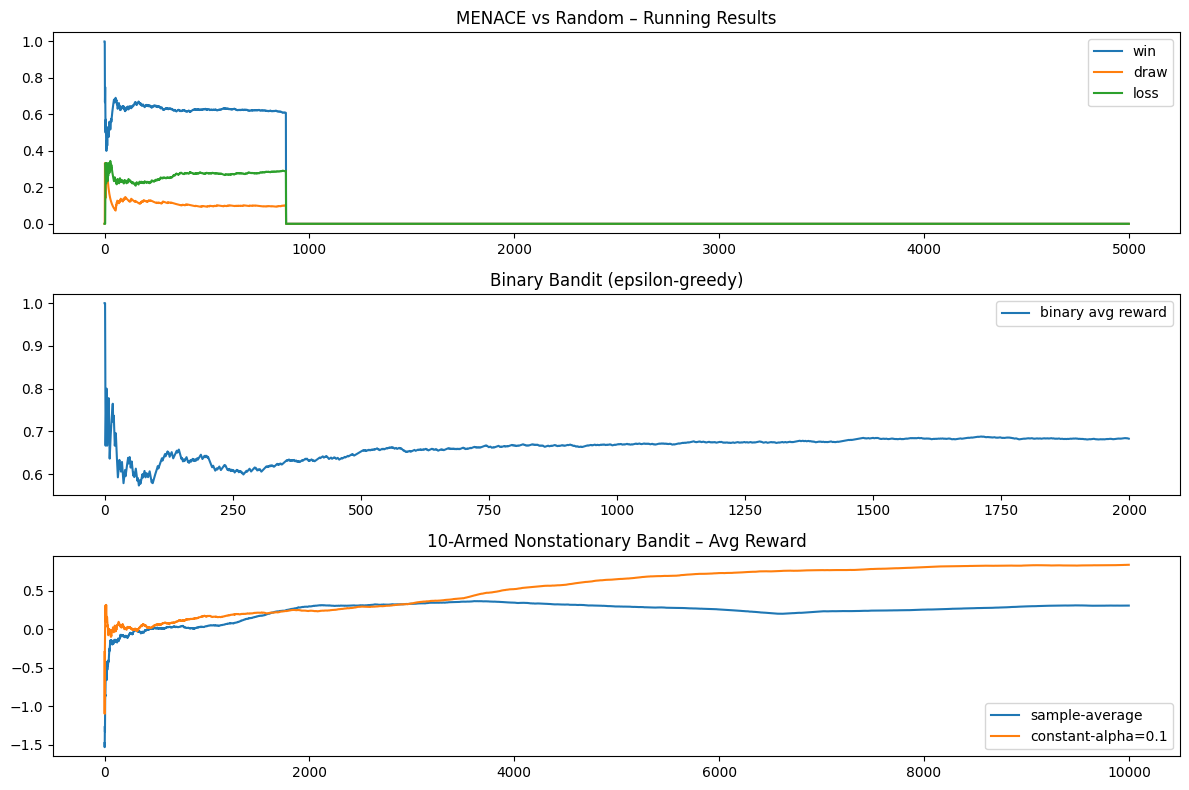

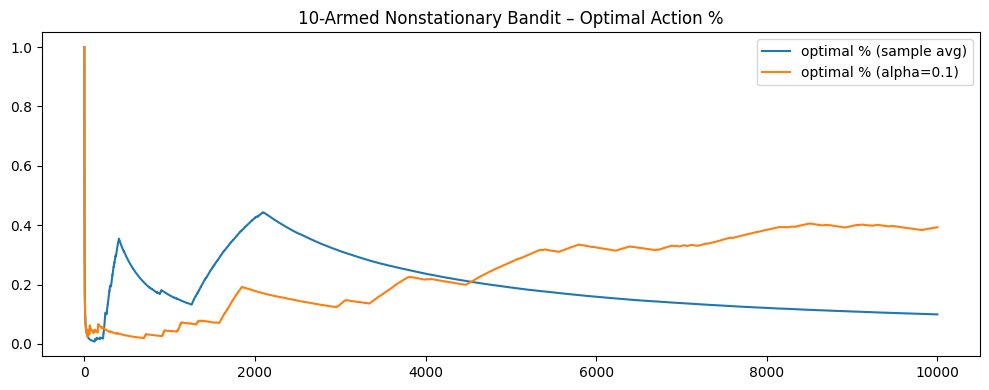

Done.


In [5]:
# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12,8))

# MENACE
plt.subplot(3,1,1)
plt.plot(wins, label='win')
plt.plot(draws, label='draw')
plt.plot(losses, label='loss')
plt.title("MENACE vs Random – Running Results")
plt.legend()

# Binary bandit
plt.subplot(3,1,2)
plt.plot(binary_rewards, label='binary avg reward')
plt.title("Binary Bandit (epsilon-greedy)")
plt.legend()

# 10-armed avg reward
plt.subplot(3,1,3)
plt.plot(rewards_avg, label='sample-average')
plt.plot(rewards_const, label='constant-alpha=0.1')
plt.title("10-Armed Nonstationary Bandit – Avg Reward")
plt.legend()

plt.tight_layout()
plt.show()

# Optimal action plot
plt.figure(figsize=(10,4))
plt.plot(opt_avg, label='optimal % (sample avg)')
plt.plot(opt_const, label='optimal % (alpha=0.1)')
plt.title("10-Armed Nonstationary Bandit – Optimal Action %")
plt.legend()
plt.tight_layout()
plt.show()

print("Done.")
